<div style="background: linear-gradient(135deg, #1b4332 0%, #2d6a4f 50%, #52b788 100%); padding: 35px 30px; border-radius: 12px; margin-bottom: 20px;">
  <h1 style="color: white; font-family: 'Segoe UI', sans-serif; font-size: 2.2em; margin: 0; font-weight: 700;">📊 Análisis Exploratorio de Datos (EDA)</h1>
  <p style="color: #d8f3dc; font-size: 1.1em; margin: 12px 0 0;">E-Commerce Churn Prediction &nbsp;|&nbsp; No Country — Equipo 40</p>
</div>

> **Dataset:** Online Retail II (UCI Machine Learning Repository)  
> **Objetivo:** Comprender la estructura, calidad y distribuciones del dataset antes de cualquier modelado  
> **Output:** Datos procesados en `data/interim/` + gráficos en `reports/figures/eda/`

---

## 📋 Tabla de Contenidos

| # | Sección | Descripción |
|---|---------|-------------|
| 1 | [⚙️ Configuración](#1-config) | Setup del entorno y dependencias |
| 2 | [📥 Carga del Dataset](#2-carga) | Carga, versionado y validación del CSV |
| 3 | [🔍 Calidad de Datos](#3-calidad) | Nulos, outliers y cancelaciones |
| 4 | [📈 Distribuciones RFM](#4-rfm) | Recency, Frequency y Monetary |
| 5 | [📅 Análisis Temporal](#5-temporal) | Revenue mensual, día y hora |
| 6 | [🌍 Análisis Geográfico](#6-geo) | Top países por revenue |
| 7 | [🔗 Correlaciones](#7-corr) | Relaciones entre variables |
| 8 | [✅ Conclusiones](#8-fin) | Hallazgos clave y próximos pasos |

---
## ⚙️ 1. Configuración del Entorno <a id='1-config'></a>

> Se configuran las rutas, se cargan las librerías y se establece el estilo visual coherente con el resto del proyecto.

In [1]:
import sys
import os
from pathlib import Path

# Agregar raíz del proyecto al path
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import warnings
warnings.filterwarnings('ignore')
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import yaml

# ── Paleta de colores enterprise ──────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'primary':   '#2d6a4f',
    'secondary': '#52b788',
    'accent':    '#1a759f',
    'warning':   '#e76f51',
    'danger':    '#d62828',
    'light':     '#d8f3dc',
    'dark':      '#1b4332',
}
sns.set_palette([v for v in COLORS.values()])

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_rows', 20)

# ── Configuración del proyecto ─────────────────────────────────
with open('config/config.yaml') as f:
    cfg = yaml.safe_load(f)

# ── Crear carpetas de salida ───────────────────────────────────
for d in ['reports/figures/eda', 'data/interim', 'data/processed']:
    Path(d).mkdir(parents=True, exist_ok=True)

print(f'✅ Entorno configurado')
print(f'   Python   : {sys.version.split()[0]}')
print(f'   pandas   : {pd.__version__}')
print(f'   numpy    : {np.__version__}')
print(f'   Proyecto : {PROJECT_ROOT}')

✅ Entorno configurado
   Python   : 3.11.9
   pandas   : 2.3.3
   numpy    : 2.4.4
   Proyecto : C:\Users\DODY DUEÑAS\Documents\ProyectoNoCountry3\proyectodechurndenocountry


---
## 📥 2. Carga y Validación del Dataset <a id='2-carga'></a>

> Se usa `DataLoader` para una carga robusta (manejo de encoding) y `DataVersioner` para calcular el hash SHA256 del dataset, garantizando reproducibilidad.

| Clase | Responsabilidad |
|-------|-----------------|
| `DataLoader` | Carga eficiente del CSV con fallback de encoding |
| `DataVersioner` | Hash SHA256 → trazabilidad del dataset |
| `DataValidator` | Controles de calidad y esquema |

In [2]:
from src.data.loader import DataLoader
from src.data.validator import DataValidator
from src.data.versioner import DataVersioner

# ── Versionado (reproducibilidad) ─────────────────────────────
versioner = DataVersioner(cfg['paths']['raw_data'])
version_info = versioner.generate_version_info()
print(f"📌 Dataset SHA256  : {version_info['sha256_hash'][:40]}...")
print(f"📦 Tamaño en disco : {version_info['size_mb']} MB")

# ── Carga del dataset ──────────────────────────────────────────
print('\n⏳ Cargando dataset...')
loader = DataLoader(cfg['paths']['raw_data'])
df = loader.load()

date_rng = loader.get_date_range()
print(f'\n✅ Dataset cargado exitosamente')
print(f'   Shape          : {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'   Rango temporal : {date_rng["min_date"].date()} → {date_rng["max_date"].date()} ({date_rng["days_span"]} días)')

📌 Dataset SHA256  : c161f3e453e8f6d6ea864258742f472c21cb5340...
📦 Tamaño en disco : 95.92 MB

⏳ Cargando dataset...



✅ Dataset cargado exitosamente
   Shape          : 1,067,371 filas × 8 columnas
   Rango temporal : 2009-12-01 → 2011-12-09 (738 días)


In [3]:
# ── Validación de esquema ──────────────────────────────────────
validator = DataValidator(raise_on_error=False)
report = validator.validate(df)
print(report.summary())

=== Validación de Datos: ✅ PASÓ ===
  Filas totales    : 1,067,371
  Nulos detectados : {'Description': 4382, 'Customer ID': 243007}
  ⚠️  Advertencias:
     - 'Customer ID' tiene 243,007 nulos (22.8%) → se eliminarán en preprocesamiento.
     - 5 registros con Price < 0 → se eliminarán en preprocesamiento.
     - 9 registros con Quantity > 10,000 (posibles outliers B2B).


In [4]:
# ── Vista general del dataset ──────────────────────────────────
print('📋 Primeras 5 filas del dataset:')
df.head()

📋 Primeras 5 filas del dataset:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
# ── Perfil de columnas ─────────────────────────────────────────
info_df = pd.DataFrame({
    'Tipo':       df.dtypes,
    'Nulos':      df.isnull().sum(),
    'Nulos %':    (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos':     df.nunique(),
})
print('📊 Perfil de columnas:')
info_df

📊 Perfil de columnas:


,Tipo,Nulos,Nulos %,Únicos
Invoice,object,0,0.00,53628
StockCode,object,0,0.00,5305
Description,object,4382,0.41,5698
Quantity,int64,0,0.00,1057
InvoiceDate,datetime64[ns],0,0.00,47635
Price,float64,0,0.00,2807
Customer ID,object,243007,22.77,5942
Country,object,0,0.00,43


---
## 🔍 3. Análisis de Calidad de Datos <a id='3-calidad'></a>

> Se identifican los principales problemas de calidad que serán tratados en la capa de preprocessing:

| Problema | Acción en pipeline |
|----------|-------------------|
| `Customer ID` nulo (~25%) | Eliminar — no podemos calcular RFM sin ID |
| Facturas canceladas (prefijo 'C') | Eliminar — son devoluciones, no compras |
| `Price` ≤ 0 | Eliminar — precios inválidos |
| `Quantity` < 0 | Eliminar — ajustes de inventario |

In [6]:
# ── Estadísticas descriptivas ──────────────────────────────────
print('📊 Estadísticas de variables numéricas:')
df[['Quantity', 'Price']].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

📊 Estadísticas de variables numéricas:


,Quantity,Price
count,"1,067,371.00","1,067,371.00"
mean,9.94,4.65
std,172.71,123.55
min,"-80,995.00","-53,594.36"
1%,-3.00,0.21
5%,1.00,0.42
25%,1.00,1.25
50%,3.00,2.10
75%,10.00,4.15
95%,30.00,9.95


In [7]:
# ── Análisis de problemas de calidad ──────────────────────────
cancelled = df[df['Invoice'].str.startswith('C', na=False)]
valid_inv  = df[~df['Invoice'].str.startswith('C', na=False)]
neg_qty    = (df['Quantity'] < 0).sum()
zero_price = (df['Price'] <= 0).sum()
null_cid   = df['Customer ID'].isnull().sum()

print('=== Resumen de Problemas de Calidad ===')
print(f'  Facturas canceladas (prefijo C) : {cancelled["Invoice"].nunique():>6,} facturas  ({len(cancelled)/len(df)*100:.1f}% de líneas)')
print(f'  Cantidad negativa                : {neg_qty:>6,} registros ({neg_qty/len(df)*100:.1f}%)')
print(f'  Precio <= 0                      : {zero_price:>6,} registros ({zero_price/len(df)*100:.1f}%)')
print(f'  Customer ID nulo                 : {null_cid:>6,} registros ({null_cid/len(df)*100:.1f}%)')
print(f'\n  → Total filas a eliminar estimado: ~{(neg_qty+zero_price+null_cid):,}')

=== Resumen de Problemas de Calidad ===
  Facturas canceladas (prefijo C) :  8,292 facturas  (1.8% de líneas)
  Cantidad negativa                : 22,950 registros (2.2%)
  Precio <= 0                      :  6,207 registros (0.6%)
  Customer ID nulo                 : 243,007 registros (22.8%)

  → Total filas a eliminar estimado: ~272,164


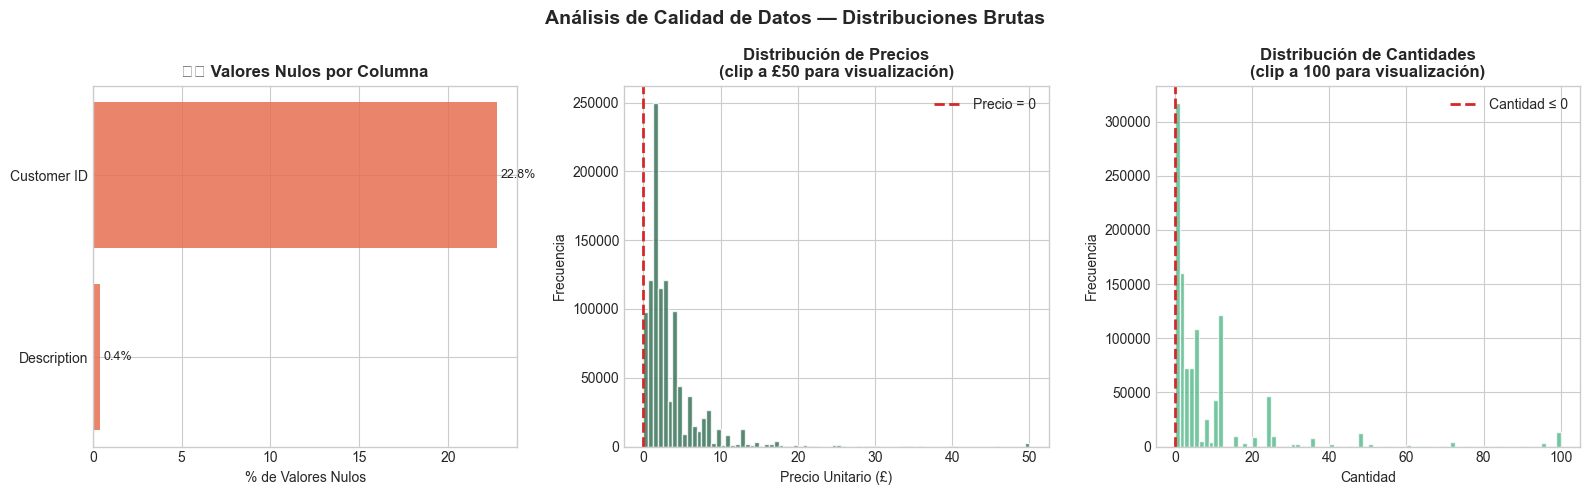

✅ Guardado: reports/figures/eda/data_quality_overview.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análisis de Calidad de Datos — Distribuciones Brutas', fontsize=14, fontweight='bold')

# Mapa de nulos
null_data = df.isnull().sum().reset_index()
null_data.columns = ['Columna', 'Nulos']
null_data['Pct'] = (null_data['Nulos'] / len(df) * 100).round(2)
null_data = null_data[null_data['Nulos'] > 0]
axes[0].barh(null_data['Columna'], null_data['Pct'], color=COLORS['warning'], alpha=0.85)
axes[0].set_xlabel('% de Valores Nulos')
axes[0].set_title('⚠️ Valores Nulos por Columna', fontweight='bold')
for i, v in enumerate(null_data['Pct']):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

# Distribución de Price
axes[1].hist(df['Price'].clip(0, 50), bins=80, color=COLORS['primary'], alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Precio Unitario (£)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Precios\n(clip a £50 para visualización)', fontweight='bold')
axes[1].axvline(0, color=COLORS['danger'], lw=2, ls='--', label='Precio = 0')
axes[1].legend()

# Distribución de Quantity
axes[2].hist(df['Quantity'].clip(0, 100), bins=80, color=COLORS['secondary'], alpha=0.8, edgecolor='white')
axes[2].set_xlabel('Cantidad')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Distribución de Cantidades\n(clip a 100 para visualización)', fontweight='bold')
axes[2].axvline(0, color=COLORS['danger'], lw=2, ls='--', label='Cantidad ≤ 0')
axes[2].legend()

plt.tight_layout()
plt.savefig('reports/figures/eda/data_quality_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: reports/figures/eda/data_quality_overview.png')

---
## 📈 4. Distribuciones de Métricas RFM <a id='4-rfm'></a>

> Las métricas **RFM** (Recency, Frequency, Monetary) son el corazón de la segmentación de clientes. Se calculan a nivel de cliente a partir de las transacciones limpias.

| Métrica | Definición | Rol en Churn |
|---------|-----------|-------------|
| **Recency** | Días desde la última compra | Predictor #1 — mayor Recency → mayor riesgo |
| **Frequency** | Facturas únicas realizadas | Indicador de lealtad |
| **Monetary** | Gasto total en £ | Indicador de valor del cliente |

In [9]:
from src.features.preprocessing import TransactionPreprocessor
from src.features.rfm_builder import RFMBuilder

print('⏳ Preprocesando transacciones...')
pre = TransactionPreprocessor()
clean_df = pre.fit_transform(df)
print(f'   Transacciones limpias: {len(clean_df):,} ({len(df)-len(clean_df):,} removidas = {(len(df)-len(clean_df))/len(df)*100:.1f}%)')

print('\n⏳ Calculando métricas RFM...')
rfm_builder = RFMBuilder(apply_log_transform=False)
rfm = rfm_builder.build(clean_df)

print(f'\n✅ RFM calculado: {len(rfm):,} clientes únicos')
rfm.describe(percentiles=[.10, .25, .50, .75, .90, .95])

⏳ Preprocesando transacciones...


   Transacciones limpias: 805,531 (261,840 removidas = 24.5%)

⏳ Calculando métricas RFM...



✅ RFM calculado: 5,878 clientes únicos


,Recency,Frequency,Monetary
count,"5,878.00","5,878.00","5,878.00"
mean,201.33,6.29,"2,352.91"
std,209.34,13.01,"4,338.25"
min,1.00,1.00,2.95
10%,9.00,1.00,163.80
25%,26.00,1.00,348.76
50%,96.00,3.00,898.91
75%,380.00,7.00,"2,307.09"
90%,535.00,13.00,"5,595.37"
95%,625.00,21.00,"9,535.34"


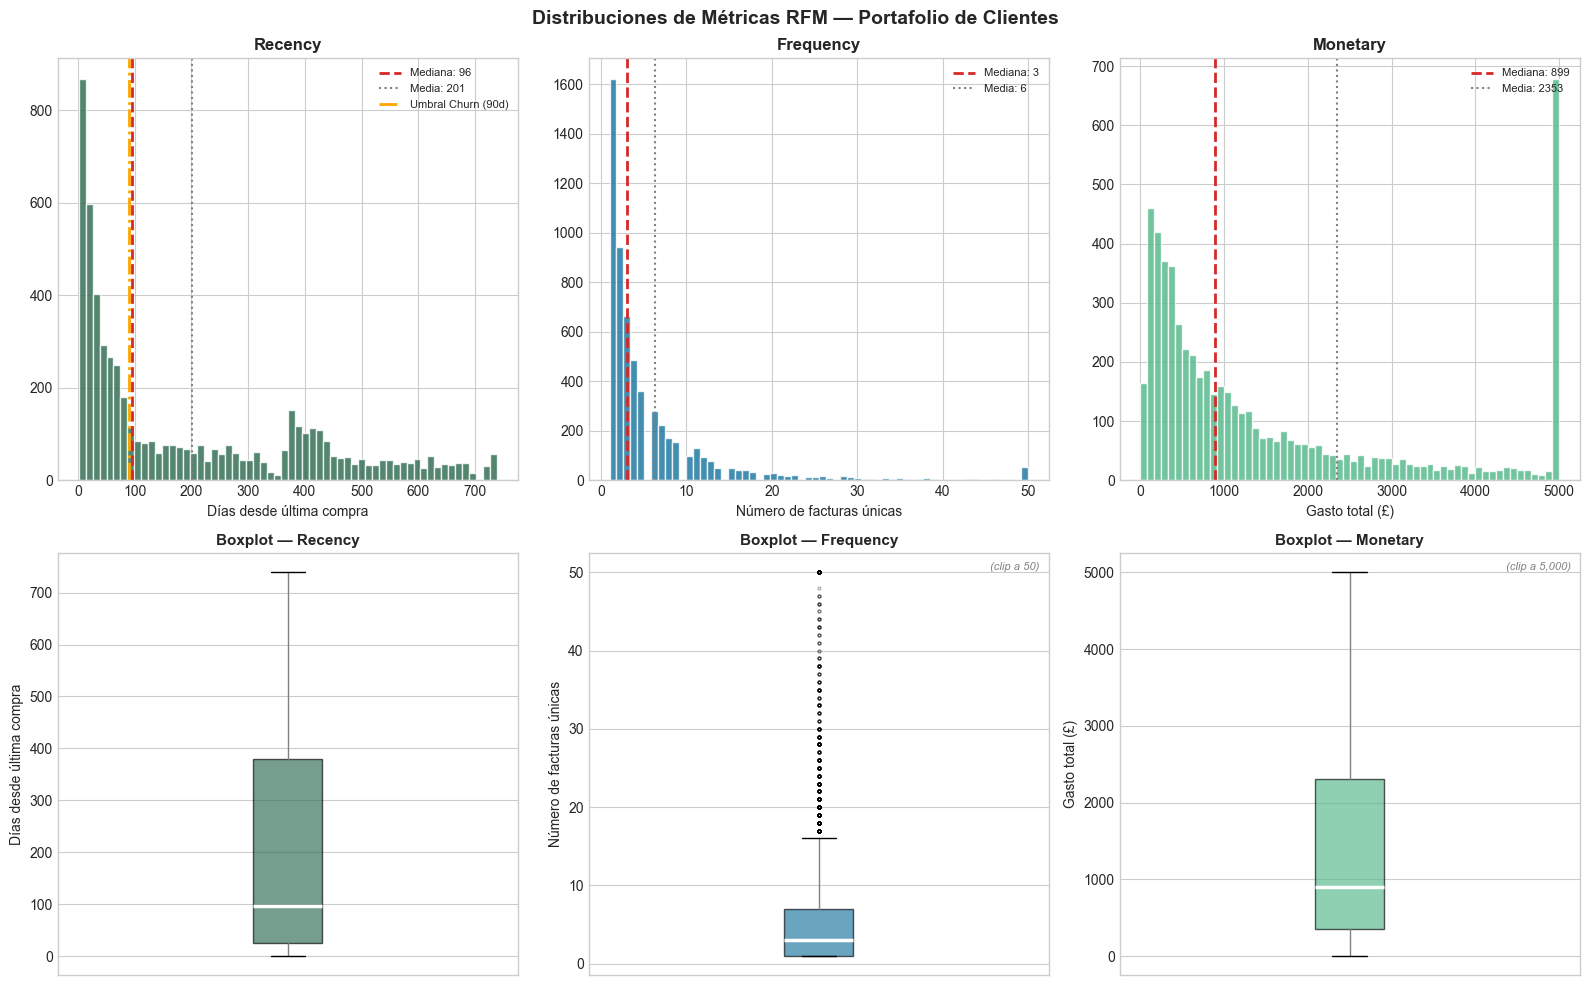

✅ Guardado: reports/figures/eda/rfm_distributions.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribuciones de Métricas RFM — Portafolio de Clientes', fontsize=14, fontweight='bold')

rfm_colors = [COLORS['primary'], COLORS['accent'], COLORS['secondary']]
rfm_cols   = ['Recency', 'Frequency', 'Monetary']
rfm_labels = ['Días desde última compra', 'Número de facturas únicas', 'Gasto total (£)']
clips      = [None, 50, 5000]

for i, (col, label, clip, color) in enumerate(zip(rfm_cols, rfm_labels, clips, rfm_colors)):
    data = rfm[col].clip(upper=clip) if clip else rfm[col]
    med  = rfm[col].median()
    mu   = rfm[col].mean()

    # Histograma
    axes[0, i].hist(data, bins=60, color=color, alpha=0.82, edgecolor='white')
    axes[0, i].axvline(med, color=COLORS['danger'], lw=2, ls='--', label=f'Mediana: {med:.0f}')
    axes[0, i].axvline(mu, color='gray', lw=1.5, ls=':', label=f'Media: {mu:.0f}')
    if col == 'Recency':
        axes[0, i].axvline(90, color='orange', lw=2, ls='-.', label='Umbral Churn (90d)')
    axes[0, i].set_xlabel(label)
    axes[0, i].set_title(f'{col}', fontweight='bold', fontsize=12)
    axes[0, i].legend(fontsize=8)

    # Boxplot
    bp = axes[1, i].boxplot(data.dropna(), vert=True, patch_artist=True,
                             boxprops=dict(facecolor=color, alpha=0.65),
                             medianprops=dict(color='white', linewidth=2.5),
                             whiskerprops=dict(color='gray'),
                             flierprops=dict(marker='o', ms=2, alpha=0.3, color=COLORS['warning']))
    axes[1, i].set_title(f'Boxplot — {col}', fontweight='bold', fontsize=11)
    axes[1, i].set_ylabel(label)
    axes[1, i].set_xticks([])
    if clip:
        axes[1, i].text(0.98, 0.98, f'(clip a {clip:,})', transform=axes[1,i].transAxes,
                        ha='right', va='top', fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('reports/figures/eda/rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: reports/figures/eda/rfm_distributions.png')

> 💡 **Observaciones:**
> - La distribución de **Recency** es aproximadamente bimodal — hay clientes muy activos (baja recencia) y clientes inactivos (alta recencia)
> - **Frequency** y **Monetary** presentan una distribución muy asimétrica a la derecha, típica de datos de e-commerce (pocos VIPs con muchas compras y alto gasto)
> - La línea naranja en Recency muestra el **umbral de 90 días** — clientes a la derecha serán etiquetados como Churn

---
## 📅 5. Análisis Temporal <a id='5-temporal'></a>

> Entender los patrones temporales es crítico para evitar introducir **data leakage** y para diseñar campañas de retención en los momentos de mayor actividad.

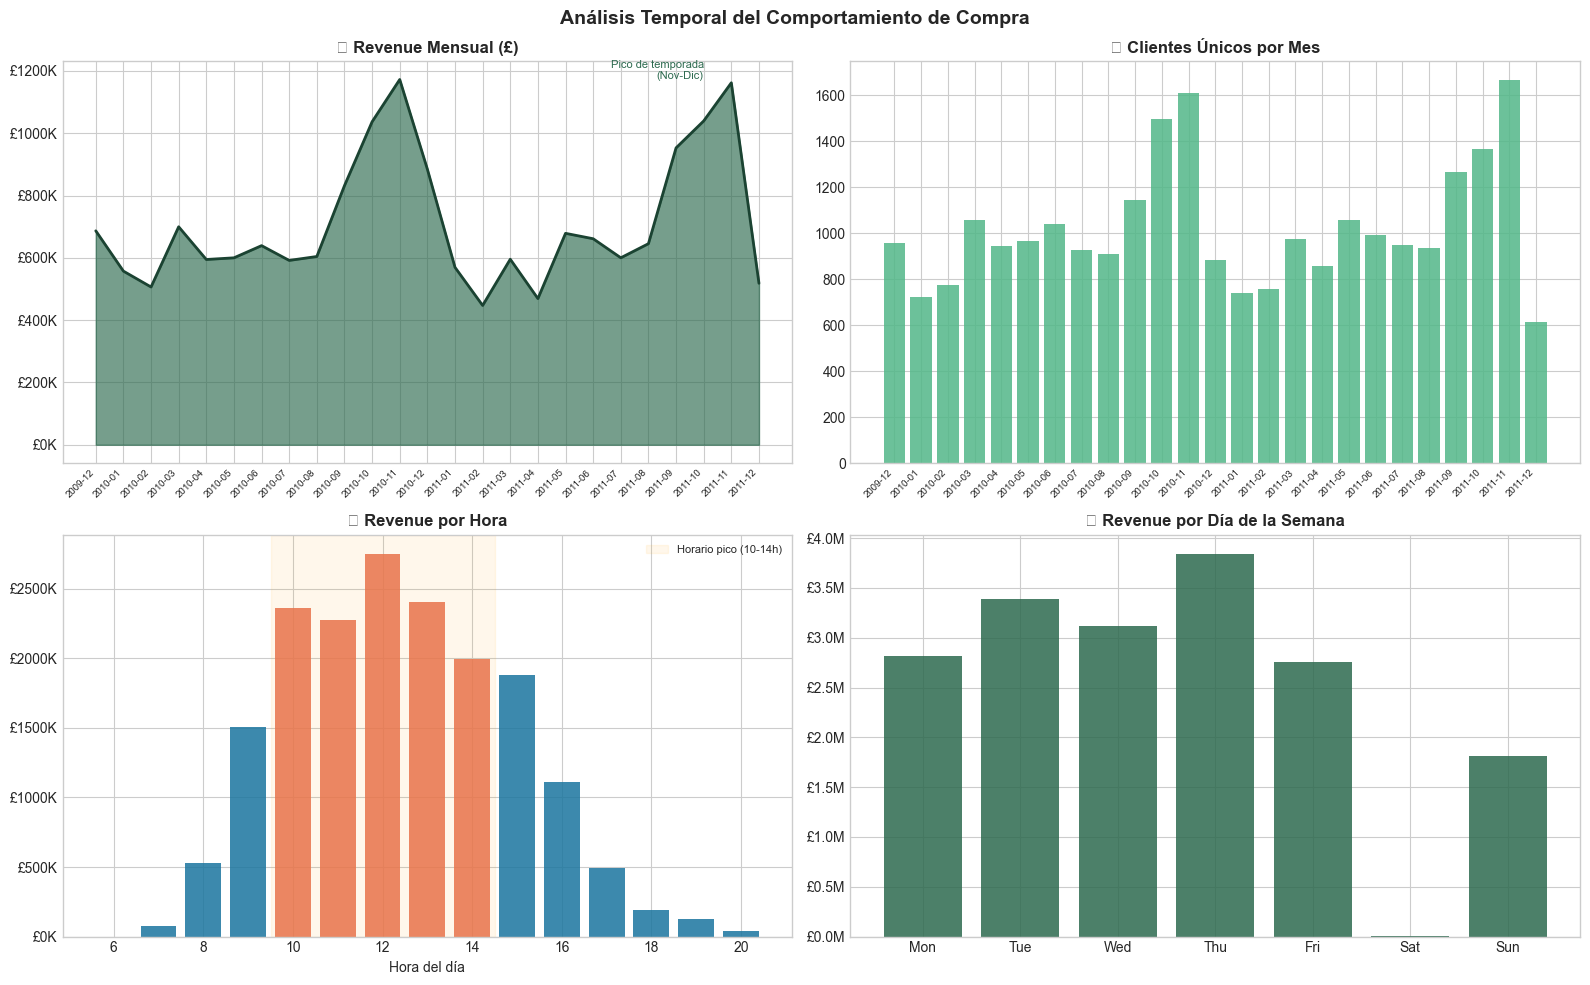

In [11]:
clean_df['TotalSum']   = clean_df['Quantity'] * clean_df['Price']
clean_df['YearMonth']  = clean_df['InvoiceDate'].dt.to_period('M')
clean_df['Hour']       = clean_df['InvoiceDate'].dt.hour
clean_df['DayOfWeek']  = clean_df['InvoiceDate'].dt.day_name()

monthly_rev = clean_df.groupby('YearMonth')['TotalSum'].sum().reset_index()
monthly_rev['YearMonth'] = monthly_rev['YearMonth'].astype(str)

monthly_cust = clean_df.groupby('YearMonth')['Customer ID'].nunique().reset_index()
monthly_cust['YearMonth'] = monthly_cust['YearMonth'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Análisis Temporal del Comportamiento de Compra', fontsize=14, fontweight='bold')

# Revenue mensual
x = range(len(monthly_rev))
axes[0,0].fill_between(x, monthly_rev['TotalSum'], color=COLORS['primary'], alpha=0.65)
axes[0,0].plot(x, monthly_rev['TotalSum'], color=COLORS['dark'], lw=2)
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(monthly_rev['YearMonth'], rotation=45, ha='right', fontsize=7)
axes[0,0].set_title('💰 Revenue Mensual (£)', fontweight='bold')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v/1000:.0f}K'))
axes[0,0].annotate('Pico de temporada\n(Nov-Dic)', xy=(len(monthly_rev)-3, monthly_rev['TotalSum'].max()),
                   fontsize=8, color=COLORS['primary'], ha='right')

# Clientes únicos por mes
x2 = range(len(monthly_cust))
axes[0,1].bar(x2, monthly_cust['Customer ID'], color=COLORS['secondary'], alpha=0.85)
axes[0,1].set_xticks(x2); axes[0,1].set_xticklabels(monthly_cust['YearMonth'], rotation=45, ha='right', fontsize=7)
axes[0,1].set_title('👥 Clientes Únicos por Mes', fontweight='bold')

# Revenue por hora
hourly = clean_df.groupby('Hour')['TotalSum'].sum()
bar_colors_h = [COLORS['warning'] if 10 <= h <= 14 else COLORS['accent'] for h in hourly.index]
axes[1,0].bar(hourly.index, hourly.values, color=bar_colors_h, alpha=0.85)
axes[1,0].axvspan(9.5, 14.5, alpha=0.08, color='orange', label='Horario pico (10-14h)')
axes[1,0].set_xlabel('Hora del día'); axes[1,0].set_title('⏰ Revenue por Hora', fontweight='bold')
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v/1000:.0f}K'))
axes[1,0].legend(fontsize=8)

# Revenue por día de la semana
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly = clean_df.groupby('DayOfWeek')['TotalSum'].sum().reindex(day_order)
bar_colors_d = [COLORS['primary'] if w not in ('Saturday','Sunday') else COLORS['neutral'] if 'neutral' in COLORS else '#adb5bd' for w in day_order]
axes[1,1].bar(range(7), weekly.values, color=COLORS['primary'], alpha=0.85)
axes[1,1].set_xticks(range(7)); axes[1,1].set_xticklabels([d[:3] for d in day_order])
axes[1,1].set_title('📆 Revenue por Día de la Semana', fontweight='bold')
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('reports/figures/eda/temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

> 💡 **Hallazgos temporales:**
> - El **revenue pico** se concentra en Q4 (Octubre-Diciembre) — temporada navideña
> - La mayor actividad de compra ocurre entre las **10h y 14h** → estrategia: enviar campañas en ese horario
> - Los **domingos** son el día de menor actividad — evitar lanzar campañas ese día

---
## 🌍 6. Análisis Geográfico <a id='6-geo'></a>

> El dataset es predominantemente **UK-centric**. Este análisis confirma el alcance del modelo y sus limitaciones geográficas.

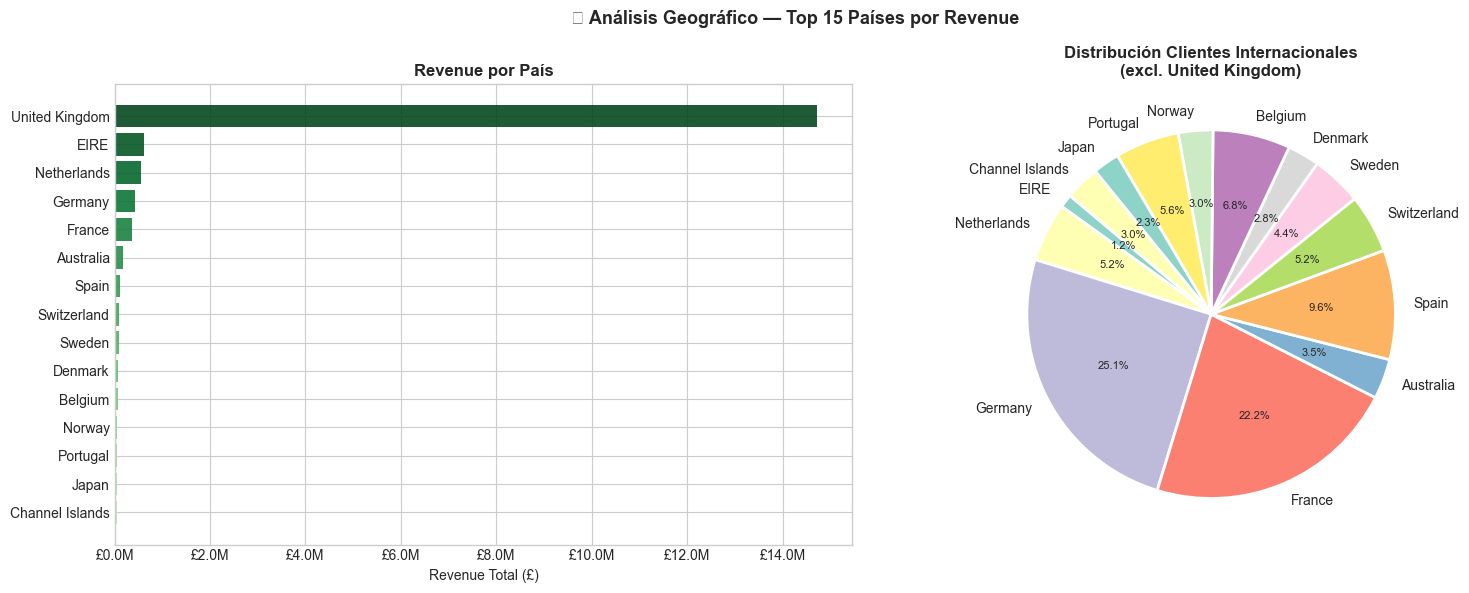

🇬🇧 United Kingdom representa el 83.0% del revenue total
   → El modelo está optimizado para el mercado UK


In [12]:
country_stats = (
    clean_df.groupby('Country')
    .agg(revenue=('TotalSum','sum'), customers=('Customer ID','nunique'), transactions=('Invoice','nunique'))
    .sort_values('revenue', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('🌍 Análisis Geográfico — Top 15 Países por Revenue', fontsize=13, fontweight='bold')

# Revenue por país (horizontal bar)
cmap = plt.get_cmap('Greens')
bar_clrs = [cmap(0.25 + 0.75 * (1 - i/len(country_stats))) for i in range(len(country_stats))]
h = axes[0].barh(country_stats.index[::-1], country_stats['revenue'][::-1], color=bar_clrs[::-1], alpha=0.88)
axes[0].set_xlabel('Revenue Total (£)')
axes[0].set_title('Revenue por País', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v/1e6:.1f}M'))

# Donut — clientes internacionales (excl. UK)
intl = country_stats[country_stats.index != 'United Kingdom']
wedges, texts, pcts = axes[1].pie(
    intl['customers'], labels=intl.index, autopct='%1.1f%%',
    colors=plt.cm.Set3.colors[:len(intl)], startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for pct in pcts:
    pct.set_fontsize(8)
axes[1].set_title('Distribución Clientes Internacionales\n(excl. United Kingdom)', fontweight='bold')

plt.tight_layout()
plt.savefig('reports/figures/eda/geographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

uk_pct = clean_df[clean_df['Country']=='United Kingdom']['TotalSum'].sum() / clean_df['TotalSum'].sum() * 100
print(f'🇬🇧 United Kingdom representa el {uk_pct:.1f}% del revenue total')
print(f'   → El modelo está optimizado para el mercado UK')

---
## 🔗 7. Correlaciones y Relaciones entre Variables <a id='7-corr'></a>

> Se analiza la relación entre las métricas RFM para detectar **multicolinealidad** que podría afectar a los modelos lineales.

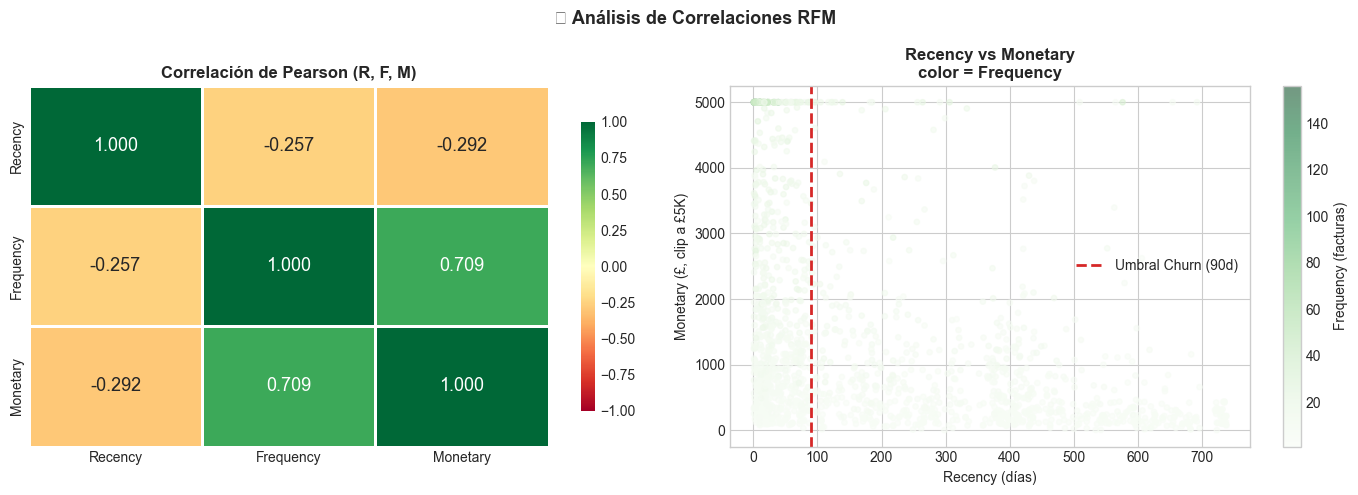

💡 Recency y Monetary muestran correlación ligeramente negativa:
   Clientes que compran más recientemente tienden a gastar más.


In [13]:
corr = rfm[['Recency','Frequency','Monetary']].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🔗 Análisis de Correlaciones RFM', fontsize=13, fontweight='bold')

# Heatmap
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, ax=axes[0], linewidths=2,
            cbar_kws={'shrink':0.8}, annot_kws={'size':13})
axes[0].set_title('Correlación de Pearson (R, F, M)', fontweight='bold')

# Scatter Recency vs Monetary
s = rfm.sample(min(1500, len(rfm)), random_state=42)
sc = axes[1].scatter(s['Recency'], s['Monetary'].clip(0,5000),
                     c=s['Frequency'], cmap='Greens', alpha=0.55, s=15, vmin=1)
plt.colorbar(sc, ax=axes[1], label='Frequency (facturas)')
axes[1].axvline(90, color=COLORS['danger'], ls='--', lw=2, label='Umbral Churn (90d)')
axes[1].set_xlabel('Recency (días)')
axes[1].set_ylabel('Monetary (£, clip a £5K)')
axes[1].set_title('Recency vs Monetary\ncolor = Frequency', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('reports/figures/eda/rfm_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Recency y Monetary muestran correlación ligeramente negativa:')
print(f'   Clientes que compran más recientemente tienden a gastar más.')

---
## ✅ 8. Conclusiones y Próximos Pasos <a id='8-fin'></a>

> Resumen de los hallazgos principales del EDA.

In [14]:
# Guardar datos procesados
clean_df.to_parquet('data/interim/cleaned_transactions.parquet', index=False)
rfm.to_parquet('data/interim/rfm_raw.parquet', index=False)

print('╔══════════════════════════════════════════════════════╗')
print('║         📋 CONCLUSIONES DEL EDA                     ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'  Dataset     : {len(df):,} transacciones brutas → {len(clean_df):,} válidas')
print(f'  Clientes    : {rfm["Customer ID"].nunique():,} únicos identificados')
print(f'  Revenue     : £{clean_df["TotalSum"].sum():,.0f} total')
print(f'  Recency med.: {rfm["Recency"].median():.0f} días')
print(f'  Frequency   : mediana {rfm["Frequency"].median():.0f} facturas/cliente')
print(f'  Monetary    : mediana £{rfm["Monetary"].median():.2f}/cliente')
print('╠══════════════════════════════════════════════════════╣')
print('  🔑 Hallazgos clave:')
print('  • Recency es la variable más discriminante para Churn')
print('  • Q4 (Oct-Dic) es la temporada de mayor actividad')
print('  • ~25% de transacciones sin Customer ID → sesgo de selección')
print('  • Dataset UK-centric → modelo optimizado para UK')
print('╠══════════════════════════════════════════════════════╣')
print('  📁 Outputs generados:')
print('  • data/interim/cleaned_transactions.parquet')
print('  • data/interim/rfm_raw.parquet')
print('  • reports/figures/eda/ (4 gráficos)')
print('╠══════════════════════════════════════════════════════╣')
print('  → Siguiente: 02_churn_definition.ipynb')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║         📋 CONCLUSIONES DEL EDA                     ║
╠══════════════════════════════════════════════════════╣
  Dataset     : 1,067,371 transacciones brutas → 805,531 válidas
  Clientes    : 5,878 únicos identificados
  Revenue     : £17,743,429 total
  Recency med.: 96 días
  Frequency   : mediana 3 facturas/cliente
  Monetary    : mediana £898.91/cliente
╠══════════════════════════════════════════════════════╣
  🔑 Hallazgos clave:
  • Recency es la variable más discriminante para Churn
  • Q4 (Oct-Dic) es la temporada de mayor actividad
  • ~25% de transacciones sin Customer ID → sesgo de selección
  • Dataset UK-centric → modelo optimizado para UK
╠══════════════════════════════════════════════════════╣
  📁 Outputs generados:
  • data/interim/cleaned_transactions.parquet
  • data/interim/rfm_raw.parquet
  • reports/figures/eda/ (4 gráficos)
╠══════════════════════════════════════════════════════╣
  → Siguiente: 02_churn_defi

<div style="background: #d8f3dc; border-left: 5px solid #2d6a4f; padding: 15px 20px; border-radius: 6px; margin-top: 20px;">
  <strong>✅ EDA completado.</strong> Los datos han sido validados, limpiados y guardados en <code>data/interim/</code>.<br>
  Continúa en <strong>02_churn_definition.ipynb</strong> para analizar y seleccionar el umbral de inactividad óptimo.
</div>